In [1]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

with open('../wo_types_comparison/wo_types_results.pkl', 'rb') as f:
    results1 = pickle.load(f)

with open('../w_types_comparison/w_types_results.pkl', 'rb') as f:
    results2 = pickle.load(f)

with open('../celltypeinitialized_comparison/celltypeinitialized_results.pkl', 'rb') as f:
    results3 = pickle.load(f)

with open('../DualMLP/dualmlps_results.pkl', 'rb') as f:
    results4 = pickle.load(f)

results = [results1, results2, results3, results4]

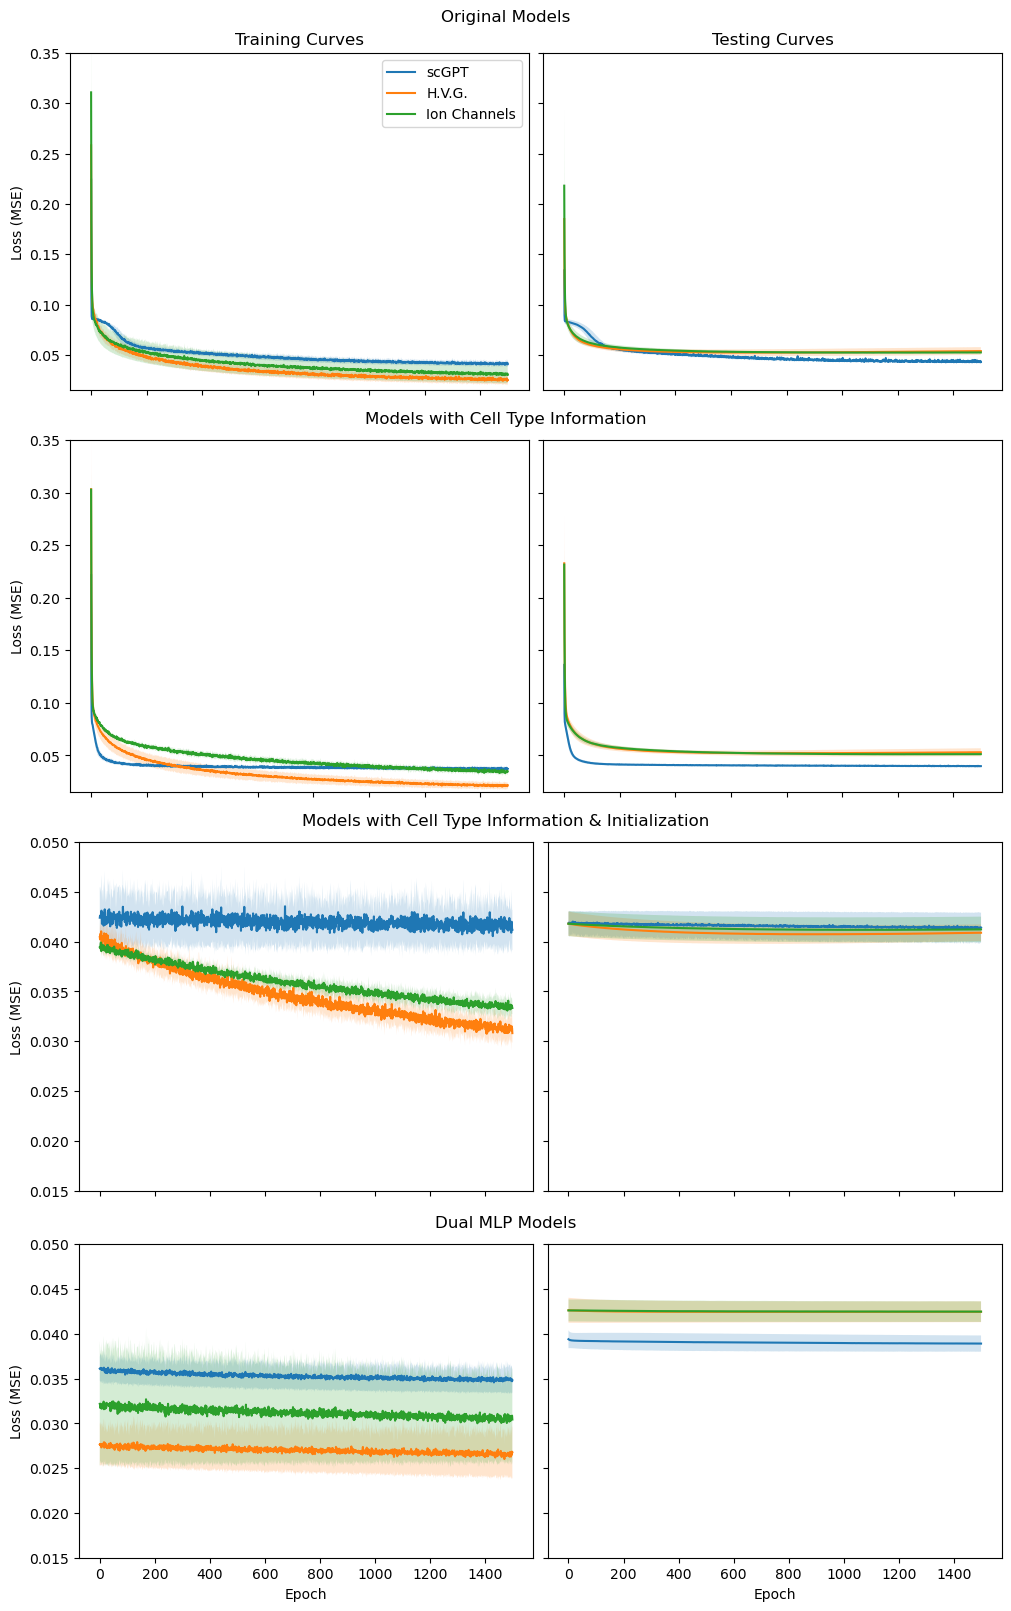

In [9]:
tests = ['Original Models', 'Models with Cell Type Information', 'Models with Cell Type Information & Initialization', 'Dual MLP Models']
models = ["scgpt", "hvg", "ion"]
labels = ["scGPT", "H.V.G.", "Ion Channels"]
ylims = [(0.015,0.35), (0.015,0.35), (0.015,0.05), (0.015,0.05)]

fig = plt.figure(figsize=(10, 16), constrained_layout=True)
subfigs = fig.subfigures(nrows=4, ncols=1)

for i, subfig in enumerate(subfigs):
    subfig.suptitle(tests[i])
    axs = subfig.subplots(nrows=1, ncols=2)

    for j, model in enumerate(models):
        avg_losses = np.mean(results[i][model]["train_losses"], axis=0)
        std_losses = np.std(results[i][model]["train_losses"], axis=0)
        axs[0].plot(range(1500), avg_losses, label=labels[j])
        axs[0].fill_between(range(1500), avg_losses - std_losses, avg_losses + std_losses, alpha=0.2)
    axs[0].set_ylabel('Loss (MSE)')
    axs[0].set_ylim(ylims[i])

    for j, model in enumerate(models):
        avg_losses = np.mean(results[i][model]["test_losses"], axis=0)
        std_losses = np.std(results[i][model]["test_losses"], axis=0)
        axs[1].plot(range(1500), avg_losses, label=labels[j])
        axs[1].fill_between(range(1500), avg_losses - std_losses, avg_losses + std_losses, alpha=0.2)
    axs[1].set_ylim(ylims[i])
    axs[1].tick_params(axis='y', labelleft=False)
    
    if i == 0:
        axs[0].set_title("Training Curves")
        axs[1].set_title("Testing Curves")
        axs[0].legend()

    for ax in axs:
        if i == len(subfigs) - 1:
            ax.set_xlabel('Epoch')
        else:
            ax.tick_params(axis='x', labelbottom=False)

plt.savefig('learningcurves.pdf')
plt.show()

In [3]:
shuffled_cell_indices1 = np.load('../wo_types_comparison/wo_types_shuffled_cell_indices.npy')
shuffled_cell_indices2 = np.load('../w_types_comparison/w_types_shuffled_cell_indices.npy')
shuffled_cell_indices3 = np.load('../celltypeinitialized_comparison/celltypeinitialized_shuffled_cell_indices.npy')
shuffled_cell_indices4 = np.load('../DualMLP/dualmlps_shuffled_cell_indices.npy')

shuffled_cell_indices = [shuffled_cell_indices1, shuffled_cell_indices2, shuffled_cell_indices3, shuffled_cell_indices4]

all_equal = all(np.array_equal(shuffled_cell_indices[0], array) for array in shuffled_cell_indices[1:])
print(all_equal)

True


In [4]:
ephys_truth1 = np.load('../wo_types_comparison/wo_types_ephys_truth.npy')
ephys_truth2 = np.load('../w_types_comparison/w_types_ephys_truth.npy')
ephys_truth3 = np.load('../celltypeinitialized_comparison/celltypeinitialized_ephys_truth.npy')
ephys_truth4 = np.load('../DualMLP/dualmlps_ephys_truth.npy')

ephys_truth = [ephys_truth1, ephys_truth2, ephys_truth3, ephys_truth4]

all_equal = all(np.array_equal(ephys_truth[0], array) for array in ephys_truth[1:])
print(all_equal)

True


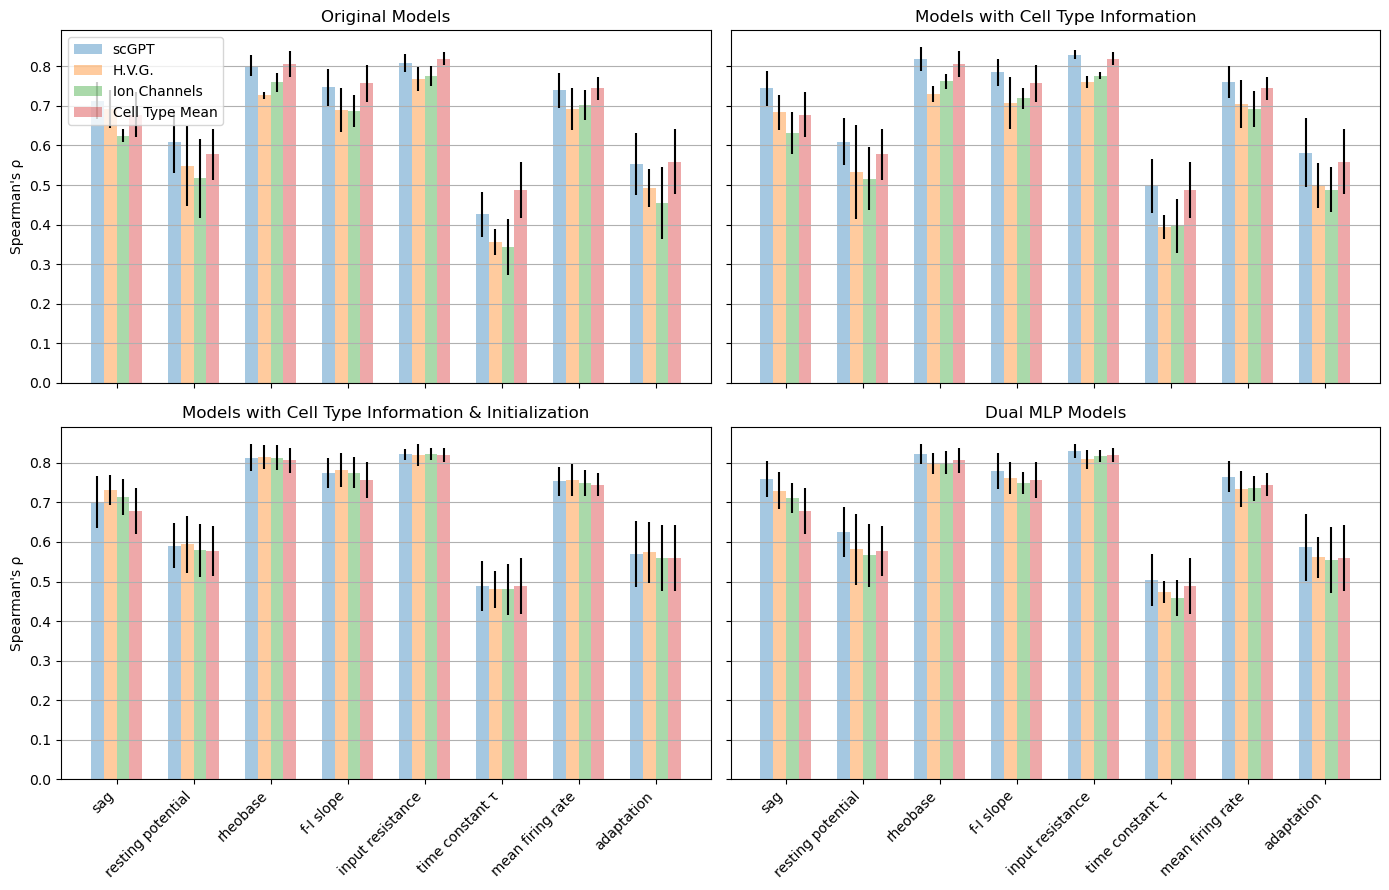

In [5]:
from scipy.stats import spearmanr
import pandas as pd

decreases = np.diff(shuffled_cell_indices1) < 0  # shuffled_cell_indices1 sorted, it decreases when starting new fold
fold_change_indices = np.where(decreases)[0] + 1
fold_change_indices = np.insert(fold_change_indices, 0, 0)
fold_change_indices = np.append(fold_change_indices, 495)

models.append("cell type mean")

def compute_rhos(test):
    rhos = {model: [] for model in models}
    for model in models:
        for i in range(len(fold_change_indices) - 1):
            rhos_foldi = []
            for feature in range(8):
                preds = results[test][model]["predictions"][fold_change_indices[i]:fold_change_indices[i+1], feature]
                truth = ephys_truth[test][fold_change_indices[i]:fold_change_indices[i+1], feature]
                rho, _ = spearmanr(preds, truth)
                rhos_foldi.append(rho)
            rhos[model].append(rhos_foldi)
    data, errors = [], []
    for model in models:
        rho_array = np.array(rhos[model])  # (n_outer_folds) x (n_ephys_features)
        data.append(np.mean(rho_array, axis=0))
        errors.append(np.std(rho_array, axis=0))
    return data, errors

labels = ["scGPT", "H.V.G.", "Ion Channels", "Cell Type Mean"]

combined_ephys_df = pd.read_pickle("../../Human/Data Preprocessing/combined_ephys_df.pkl")
feature_names = [col for col in combined_ephys_df.columns if col != "SpecimenID"]
feature_names[1] = "resting potential"

fig, axs = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)
axs = axs.flatten()

x = np.arange(8) * 1.2   # label locations
width = 0.2              # bar width

for i, ax in enumerate(axs):
    ax.set_title(tests[i])

    data, errors = compute_rhos(i)
    for multiplier, (group_label, group_data, group_error) in enumerate(zip(labels, data, errors)):
        ax.bar(x + width * multiplier, group_data, width,
               label=group_label, alpha=0.4, yerr=group_error)

    ax.yaxis.grid(True)

    if i % 2 == 0:
        ax.set_ylabel("Spearman's ρ")
    if i == 0:
        ax.legend()

    if i >= 2:
        ax.set_xticks(x + width * 1.5, feature_names, rotation=45, ha="right")
    else:
        ax.tick_params(axis="x", labelbottom=False)

fig.tight_layout()
plt.savefig("rhobarchart.pdf", bbox_inches="tight")
plt.show()

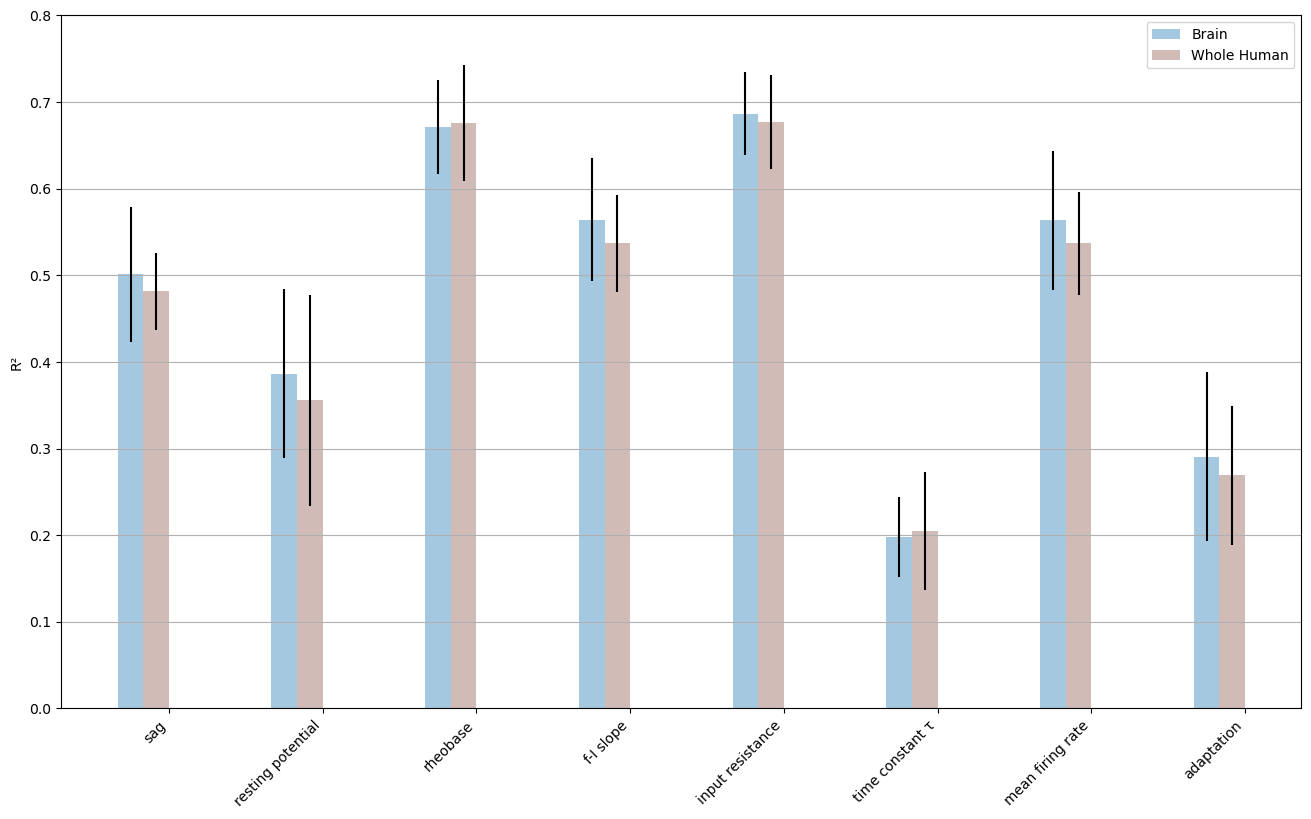

In [6]:
with open('humanscgpt_results.pkl', 'rb') as f:
    humanscgpt_results = pickle.load(f)
    
humanscgpt_results = humanscgpt_results["humanscgpt"]
brainscgpt_results = results1["scgpt"]

labels2 = ["Brain", "Whole Human"]
data = []
errors = []

data.append(np.mean(brainscgpt_results["r2_scores"][:,-1,:], axis=0))
errors.append(np.std(brainscgpt_results["r2_scores"][:,-1,:], axis=0))

data.append(np.mean(humanscgpt_results["r2_scores"][:,-1,:], axis=0))
errors.append(np.std(humanscgpt_results["r2_scores"][:,-1,:], axis=0))

x = np.arange(8)*1.2  # the label locations
width = 0.2  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(figsize=(16, 9))
colors = ["C0","C5"]
for group_label, group_data, group_error, color in zip(labels2, data, errors, colors):
    offset = width * multiplier
    rects = ax.bar(x + offset, group_data, width, label=group_label, alpha=0.4, yerr=group_error, color=color)
    multiplier += 1

feature_names = [col for col in combined_ephys_df.columns if col != "SpecimenID"]
feature_names[1] = "resting potential"
ax.set_xticks(x + width*1.5, feature_names, rotation=45, ha="right")
plt.ylim(0, 0.8)
ax.set_ylabel("R²")
ax.legend()
ax.yaxis.grid(True)
plt.savefig("scgptbrainvshuman.pdf", bbox_inches="tight")
plt.show()